🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...
1. Đang tải và ép cân dữ liệu Calendar...
---> Dung lượng ban đầu: 0.21 MB
---> Dung lượng sau khi tối ưu: 0.19 MB

2. Đang tải dữ liệu Sales...

3. Đang Melt (kéo giãn) dữ liệu Sales...

4. Đang Merge Sales với Calendar...

5. Ép cân lần cuối cho DataFrame tổng...
---> Dung lượng ban đầu: 1568.97 MB
---> Dung lượng sau khi tối ưu: 620.78 MB
-> Đang load dữ liệu Giá (sell_prices.csv)...
-> Đang hợp nhất và tính toán độ co giãn giá...
-> Đang xử lý Sự kiện lễ tết (Calendar Events)...
-> Đang tạo Đặc trưng Thời gian (Time Features)...

✅ Pipeline Dữ liệu hoàn tất! Sẵn sàng cho Machine Learning.

🎯 Đang huấn luyện cho sản phẩm: 1437 tại 0
Đang huấn luyện mô hình...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[114]	training's rmse: 0.479606	valid_1's rmse: 1.21525

Đang chạy mô phỏng tối ưu hóa Tồn kho...

📦 BÁO CÁO HÀNH ĐỘNG (SMART INVENTORY REPORT) 📦
Mã sản phẩm: 		1437
Nhóm nhu cầu: 		Intermittent (Ng

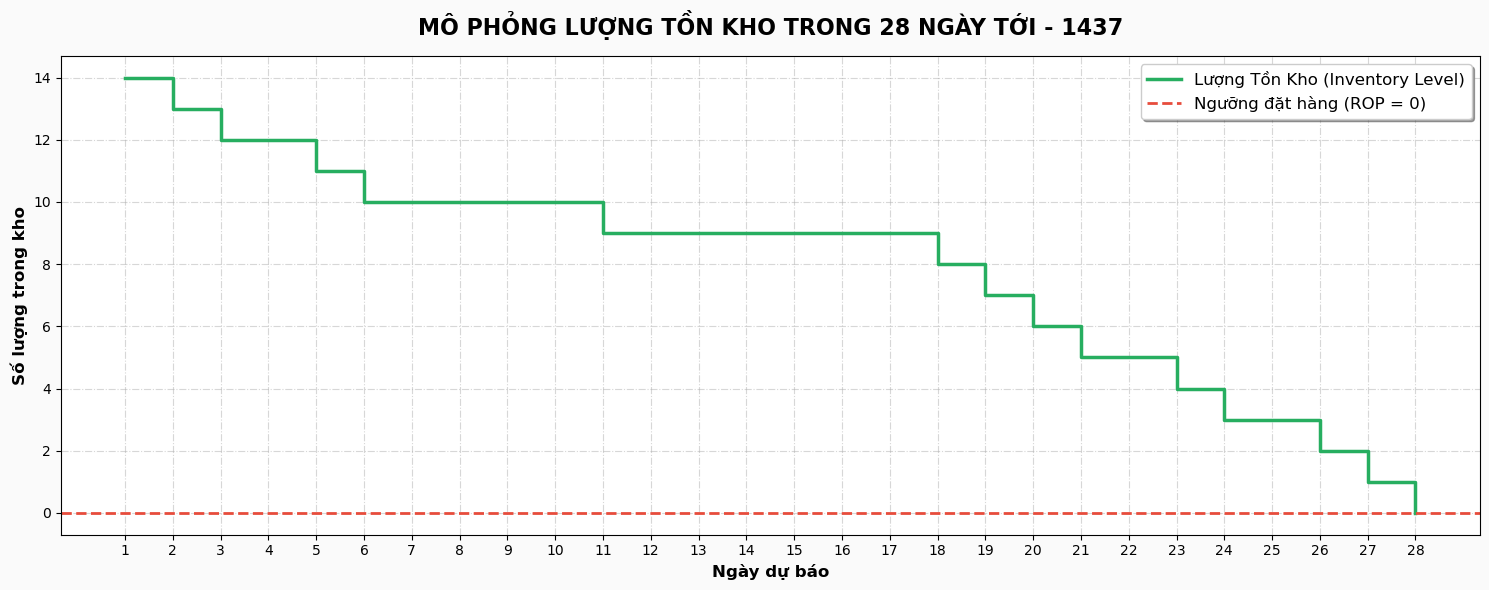

In [2]:
import sys
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Trỏ đường dẫn để gọi các hàm đã đóng gói trong thư mục src
sys.path.append(os.path.abspath('../src'))
from dataPreprocessing import load_and_preprocess_raw
from featureEngineering import generate_all_features, create_lag_features_for_item

RAW_DIR = '../dataset/raw/'

# ==========================================
# BƯỚC 1 & 2: TIỀN XỬ LÝ & TRÍCH XUẤT ĐẶC TRƯNG
# ==========================================
print("🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...")
# Lấy 10,000 dòng để train nhanh (Khi báo cáo thực tế có thể bỏ nrows=10000 đi)
df_master = load_and_preprocess_raw(RAW_DIR, nrows=10000)
df_featured = generate_all_features(df_master, RAW_DIR)

print("\n✅ Pipeline Dữ liệu hoàn tất! Sẵn sàng cho Machine Learning.\n")

# ==========================================
# BƯỚC 4: CHUẨN BỊ TẬP TRAIN CHO 1 SẢN PHẨM
# ==========================================
sample_item = df_featured['item_id'].iloc[0]
sample_store = df_featured['store_id'].iloc[0]
print(f"🎯 Đang huấn luyện cho sản phẩm: {sample_item} tại {sample_store}")

df_item = df_featured[(df_featured['item_id'] == sample_item) & (df_featured['store_id'] == sample_store)].copy()
# Gọi hàm tạo Lag & Rolling từ file featureEngineering.py
df_item = create_lag_features_for_item(df_item)

# Chia tập Train (Quá khứ) và Test (28 ngày cuối)
train_data = df_item.iloc[:-28]
test_data = df_item.iloc[-28:]

features = [
    'day', 'is_weekend',
    'sell_price', 'price_discount', 'price_momentum',
    'event_name_1',
    'lag_7', 'lag_14', 'rolling_mean_7'
]
target = 'demand'

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

# ==========================================
# BƯỚC 5: HUẤN LUYỆN LIGHTGBM TWEEDIE
# ==========================================
params = {
    'objective': 'tweedie', 
    'tweedie_variance_power': 1.1,
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'force_col_wise': True
}

categorical_features = ['event_name_1']
train_set = lgb.Dataset(X_train, y_train, categorical_feature=categorical_features)
test_set = lgb.Dataset(X_test, y_test, reference=train_set, categorical_feature=categorical_features)

print("Đang huấn luyện mô hình...")
model = lgb.train(
    params, 
    train_set, 
    num_boost_round=600, 
    valid_sets=[train_set, test_set],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

y_pred = model.predict(X_test)

# ==========================================
# BƯỚC 6 & 7: MÔ PHỎNG TỒN KHO & BÁO CÁO
# ==========================================
print("\nĐang chạy mô phỏng tối ưu hóa Tồn kho...")
daily_demand_forecast = np.maximum(np.round(y_pred), 0).astype(int)

LEAD_TIME = 3            
ORDERING_COST = 50.0     
HOLDING_COST = 0.5       
STOCKOUT_COST = 5.0      
INITIAL_INVENTORY = 15   

def simulate_inventory(demand_array, ROP, Q):
    """Mô phỏng và ghi lại lịch sử tồn kho từng ngày"""
    inventory = INITIAL_INVENTORY
    total_holding_cost = total_stockout_cost = total_ordering_cost = 0
    days_to_arrival = 0
    order_placed = False
    inventory_history = []
    
    for demand in demand_array:
        if order_placed and days_to_arrival == 0:
            inventory += Q
            order_placed = False
            
        if inventory >= demand:
            inventory -= demand
        else:
            total_stockout_cost += (demand - inventory) * STOCKOUT_COST
            inventory = 0
            
        total_holding_cost += inventory * HOLDING_COST
        
        if inventory <= ROP and not order_placed:
            total_ordering_cost += ORDERING_COST
            order_placed = True
            days_to_arrival = LEAD_TIME
            
        if order_placed:
            days_to_arrival -= 1
            
        inventory_history.append(inventory)
            
    total_cost = total_holding_cost + total_stockout_cost + total_ordering_cost
    return total_cost, inventory_history

best_cost, best_ROP, best_Q = float('inf'), 0, 0
best_history = []

# Chạy hàng ngàn kịch bản tìm tối ưu
for rop in range(0, 50, 2):
    for q in range(10, 150, 5):
        cost, history = simulate_inventory(daily_demand_forecast, rop, q)
        if cost < best_cost:
            best_cost, best_ROP, best_Q, best_history = cost, rop, q, history

print("\n" + "="*60)
print("📦 BÁO CÁO HÀNH ĐỘNG (SMART INVENTORY REPORT) 📦")
print("="*60)
print(f"Mã sản phẩm: \t\t{sample_item}")
print(f"Nhóm nhu cầu: \t\tIntermittent (Ngắt quãng)") 
print(f"Tồn kho hiện tại: \t{INITIAL_INVENTORY} sản phẩm")
print("-" * 60)
print(f"🎯 Điểm đặt hàng lại (ROP):\t{best_ROP} sản phẩm")
print(f"📦 Số lượng cần nhập (EOQ): \t{best_Q} sản phẩm / lần đặt")
print("="*60)
print(f"💰 Tổng chi phí dự kiến nếu làm theo AI: ${best_cost:,.2f}")
print("="*60)

# ==========================================
# VẼ BIỂU ĐỒ VÀ LƯU ẢNH TỰ ĐỘNG
# ==========================================
plt.figure(figsize=(15, 6), facecolor='#FAFAFA')

plt.step(range(1, 29), best_history, where='post', color='#27AE60', linewidth=2.5, label='Lượng Tồn Kho (Inventory Level)')
plt.axhline(y=best_ROP, color='#E74C3C', linestyle='--', linewidth=2, label=f'Ngưỡng đặt hàng (ROP = {best_ROP})')

plt.title(f"MÔ PHỎNG LƯỢNG TỒN KHO TRONG 28 NGÀY TỚI - {sample_item}", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Ngày dự báo", fontsize=12, fontweight='bold')
plt.ylabel("Số lượng trong kho", fontsize=12, fontweight='bold')
plt.xticks(range(1, 29))
plt.grid(True, linestyle='-.', alpha=0.5)
plt.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)
plt.tight_layout()

# Tự động tạo thư mục docs/images nếu chưa có và lưu ảnh siêu nét
os.makedirs('../docs/images', exist_ok=True)
plt.savefig('../docs/images/bieu_do_ton_kho.png', dpi=300, bbox_inches='tight')
print(f"📸 Đã lưu ảnh biểu đồ thành công tại: ../docs/images/bieu_do_ton_kho.png")

plt.show()